# Domain Adaptation: Fine-Tuning Bentham TrOCR on George Washington Dataset

## Objective
To improve my Fine-tuned TrOCR model on transcribing GW dataset, I will now take the TrOCR model already fine-tuned on Bentham and adapt it to the George Washington (GW) dataset using 4-fold cross-validation. Each fold fine-tunes from the same Bentham checkpoint to ensure comparable results across folds.

### Key design decisions
- Each fold starts from the same `best_ar` (Bentham checkpoint from Alex)
- Learning rate `1e-6` — much smaller than Bentham fine-tuning to avoid overwriting learned features
- Maximum 3 epochs per fold with early stopping on val CER
- Augmentation applied to GW train lines only, not eval lines
- All three split files (train + val + test) used for final evaluation per fold

In [1]:
from pathlib import Path
import os
import copy
import random

import pandas as pd
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torchvision import transforms

from transformers import (
    TrOCRProcessor,
    VisionEncoderDecoderModel,
    get_linear_schedule_with_warmup
)

import editdistance
from jiwer import wer
from tqdm import tqdm

In [2]:
RSEED = 42

random.seed(RSEED)
np.random.seed(RSEED)
torch.manual_seed(RSEED)

if torch.backends.mps.is_available():
    print('True')
    torch.mps.manual_seed(RSEED)

True


In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: mps


In [4]:
GW_ROOT             = Path("data") 
BENTHAM_MODEL_PATH  = Path("best_ar")  

GW_LINES_DIR          = GW_ROOT / "washingtondb-v1.0" / "data" / "line_images_normalized"
GW_TRANSCRIPTION_FILE = GW_ROOT / "washingtondb-v1.0" / "ground_truth" / "transcription.txt"
GW_SETS_DIR           = GW_ROOT / "washingtondb-v1.0" / "sets"

# Adapted models will be saved here (one per fold)
OUTPUT_MODELS_DIR = Path("./gw_adapted_models")
OUTPUT_MODELS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_CSV = Path("gw_domain_adaptation_results.csv")

# Sanity check
for p in [GW_LINES_DIR, GW_TRANSCRIPTION_FILE, GW_SETS_DIR, BENTHAM_MODEL_PATH]:
    status = "OK" if p.exists() else "NOT FOUND"
    print(f"[{status}] {p}")

[OK] data/washingtondb-v1.0/data/line_images_normalized
[OK] data/washingtondb-v1.0/ground_truth/transcription.txt
[OK] data/washingtondb-v1.0/sets
[OK] best_ar


In [5]:
SPECIAL_CHARS = {
    "s_pt":  ".",
    "s_cm":  ",",
    "s_mi":  "-",
    "s_qo":  ":",
    "s_sq":  ";",
    "s_et":  "&",
    "s_bl":  "|",
    "s_br":  " ",
    "s_1st": "1st",
    "s_s":   "s",   # long s — treated as regular s
}

def decode_gw_word(word_str):
    """Convert a single GW word token (e.g. 't-h-e' or 's_pt') to plain text."""
    chars  = word_str.split("-")
    result = ""
    for ch in chars:
        result += SPECIAL_CHARS.get(ch, ch)
    return result


def decode_gw_line(raw_line):
    """
    Parse one line from transcription.txt.
    Format: '270-01 word1|word2|word3'
    Returns: (line_id, plain_text) or (None, None) if malformed.
    """
    parts = raw_line.strip().split(" ", 1)
    if len(parts) < 2:
        return None, None
    line_id = parts[0]
    words   = parts[1].split("|")
    text    = " ".join(decode_gw_word(w) for w in words)
    return line_id, text


# Sanity check
test_raw = "270-01 t-h-e|s_pt|q-u-i-c-k"
lid, txt = decode_gw_line(test_raw)
print(f"Line ID : {lid}")
print(f"Decoded : {txt}")

Line ID : 270-01
Decoded : the . quick


In [6]:
# Load all GW transcriptions into a dictionary
gw_transcriptions = {}

with open(GW_TRANSCRIPTION_FILE, "r", encoding="utf-8") as f:
    for raw_line in f:
        line_id, text = decode_gw_line(raw_line)
        if line_id and text:
            gw_transcriptions[line_id] = text

print(f"Total transcribed lines loaded: {len(gw_transcriptions)}")
print("\nSample entries:")
for k, v in list(gw_transcriptions.items())[:5]:
    print(f"  {k}  →  {v}")

Total transcribed lines loaded: 656

Sample entries:
  270-01  →  s_2s_7s_0. Letters, Orders and Instructions. October s_1s_7s_5s_5.
  270-03  →  only for the publick use, unless by particu-
  270-04  →  lar Orders from me. You are to send
  270-05  →  down a Barrel of Flints with the Arms, to
  270-06  →  Winchester, and about two thousand weight


In [7]:
# Augmentation pipeline — same policy as Bentham training
# GW images are binarized so color jitter has limited effect,
# but rotation and blur still help generalization
gw_train_augment = transforms.Compose([
    transforms.RandomRotation(degrees=2, fill=255),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
    ], p=0.2),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])


def load_image(image_path):
    """Shared image loading: grayscale -> CLAHE -> RGB PIL image."""
    gray     = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return Image.fromarray(cv2.cvtColor(enhanced, cv2.COLOR_GRAY2RGB))


class GWTrainDataset(Dataset):
    """GW dataset with augmentation — for fine-tuning only."""

    def __init__(self, line_ids, image_dir, transcriptions, processor):
        self.line_ids = [
            lid for lid in line_ids
            if lid in transcriptions
            and (image_dir / f"{lid}.png").exists()
        ]
        self.image_dir      = image_dir
        self.transcriptions = transcriptions
        self.processor      = processor

        skipped = len(line_ids) - len(self.line_ids)
        if skipped:
            print(f"  [Train] Skipped {skipped} IDs (missing image or transcription)")

    def __len__(self):
        return len(self.line_ids)

    def __getitem__(self, idx):
        line_id = self.line_ids[idx]
        image   = load_image(self.image_dir / f"{line_id}.png")
        image   = gw_train_augment(image)   # augmentation applied here
        text    = self.transcriptions[line_id]

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}


class GWEvalDataset(Dataset):
    """GW dataset without augmentation — for validation and evaluation."""

    def __init__(self, line_ids, image_dir, transcriptions, processor):
        self.line_ids = [
            lid for lid in line_ids
            if lid in transcriptions
            and (image_dir / f"{lid}.png").exists()
        ]
        self.image_dir      = image_dir
        self.transcriptions = transcriptions
        self.processor      = processor

        skipped = len(line_ids) - len(self.line_ids)
        if skipped:
            print(f"  [Eval] Skipped {skipped} IDs (missing image or transcription)")

    def __len__(self):
        return len(self.line_ids)

    def __getitem__(self, idx):
        line_id = self.line_ids[idx]
        image   = load_image(self.image_dir / f"{line_id}.png")
        text    = self.transcriptions[line_id]

        pixel_values = self.processor(
            image, return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text, return_tensors="pt"
        ).input_ids.squeeze()

        return {"pixel_values": pixel_values, "labels": labels, "text": text}

### Load Bentham checkpoint

This is the starting point for every fold. We load it once here and use `copy.deepcopy` inside the fold loop to reset cleanly between folds without reloading from disk each time.

In [8]:
processor = TrOCRProcessor.from_pretrained(str(BENTHAM_MODEL_PATH))
tokenizer = processor.tokenizer

# Load once — deepcopy resets to this at the start of each fold
bentham_model = VisionEncoderDecoderModel.from_pretrained(str(BENTHAM_MODEL_PATH))
bentham_model.to(device)

print("Bentham checkpoint loaded on", device)
print(f"Tokenizer vocab size: {tokenizer.vocab_size}")

Loading weights:   0%|          | 0/480 [00:00<?, ?it/s]

Bentham checkpoint loaded on mps
Tokenizer vocab size: 50265


In [9]:
def collate_fn(batch):

    pixel_values = torch.stack(
        [item["pixel_values"] for item in batch]
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        [item["labels"] for item in batch],
        batch_first=True,
        padding_value=tokenizer.pad_token_id
    )

    # Mask padding so it is ignored in loss
    labels[labels == tokenizer.pad_token_id] = -100

    return {"pixel_values": pixel_values, "labels": labels}

In [10]:
def cer(pred, gt):
    if len(gt) == 0:
        return 1.0
    return editdistance.eval(pred, gt) / len(gt)


def compute_wer(pred, gt):
    return wer(gt, pred)   # jiwer expects (reference, hypothesis)


def predict(model, pixel_values, num_beams=4):
    """Run beam search inference. Model is passed explicitly for clarity inside fold loop."""
    with torch.no_grad():
        generated_ids = model.generate(
            pixel_values,
            num_beams=num_beams,
            early_stopping=True,
            max_new_tokens=128,
            no_repeat_ngram_size=3,
        )
    return processor.batch_decode(
        generated_ids, skip_special_tokens=True
    )

In [11]:
def evaluate(model, loader, desc="Evaluating"):

    model.eval()

    total_cer = 0
    total_wer = 0
    count     = 0

    with torch.no_grad():

        for batch in tqdm(loader, desc=desc):

            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"]

            preds = predict(model, pixel_values)

            for i in range(len(preds)):

                pred   = preds[i]
                gt_ids = labels[i].clone()

                # Remove ignore tokens
                gt_ids[gt_ids == -100] = tokenizer.pad_token_id

                gt = tokenizer.decode(
                    gt_ids, skip_special_tokens=True
                )

                total_cer += cer(pred, gt)
                total_wer += compute_wer(pred, gt)
                count     += 1

    return total_cer / count, total_wer / count

#### Fine-tuning hyperparameters

Much smaller learning rate than Bentham fine-tuning (`1e-6` vs `5e-6`) to push the model toward GW without overwriting Bentham features.

In [12]:
BATCH_SIZE   = 4
LEARNING_RATE = 1e-6
NUM_EPOCHS   = 3      # small — GW train set per fold is ~400-500 lines
PATIENCE     = 2      # early stopping on val CER

In [13]:
def load_ids(filepath):
    """Load line IDs from a fold split file. Returns empty list if file missing."""
    if not Path(filepath).exists():
        print(f"  [WARNING] Not found: {filepath}")
        return []
    with open(filepath, "r", encoding="utf-8") as f:
        return [line.strip() for line in f if line.strip()]


#### 4-fold cross-validation: fine-tune then evaluate

For each fold:
1. Reset model to Bentham checkpoint via `deepcopy`
2. Fine-tune on GW train lines with early stopping on GW val lines
3. Validate on valid GW lines in the fold
3. Evaluate on test GW lines in the fold
4. Save the adapted model for this fold

In [14]:
all_fold_results = []

for fold in range(1, 5):

    print(f"\n{'='*60}")
    print(f" FOLD {fold} / 4")
    print(f"{'='*60}")

    fold_dir = GW_SETS_DIR / f"cv{fold}"

    # ── Load split IDs ──────────────────────────────────────────
    train_ids = load_ids(fold_dir / "train.txt")
    valid_ids   = load_ids(fold_dir / "valid.txt")
    test_ids  = load_ids(fold_dir / "test.txt")   # only these for final eval

    print(f"  Train lines : {len(train_ids)}")
    print(f"  Val lines   : {len(valid_ids)}")
    print(f"  Test lines  : {len(test_ids)}")

    # ── Build datasets ──────────────────────────────────────────
    train_dataset = GWTrainDataset(
        train_ids, GW_LINES_DIR, gw_transcriptions, processor
    )
    valid_dataset = GWEvalDataset(
        valid_ids, GW_LINES_DIR, gw_transcriptions, processor
    )
    eval_dataset = GWEvalDataset(
        test_ids, GW_LINES_DIR, gw_transcriptions, processor   # test only
    )

    # ── Build dataloaders ───────────────────────────────────────
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate_fn
    )
    valid_loader = DataLoader(
        valid_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )
    eval_loader = DataLoader(
        eval_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate_fn
    )

    # ── Reset model to Bentham checkpoint ───────────────────────
    model = copy.deepcopy(bentham_model)
    model.to(device)
    model.train()

    # ── Optimiser and scheduler ─────────────────────────────────
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

    total_steps  = len(train_loader) * NUM_EPOCHS
    warmup_steps = int(0.1 * total_steps)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # ── Fine-tuning loop ────────────────────────────────────────
    best_valid_cer       = float("inf")
    early_stop_counter = 0
    best_model_state   = None

    for epoch in range(NUM_EPOCHS):

        model.train()
        total_loss = 0

        for batch in tqdm(
            train_loader,
            desc=f"Fold {fold} | Epoch {epoch+1}/{NUM_EPOCHS}"
        ):
            pixel_values = batch["pixel_values"].to(device)
            labels       = batch["labels"].to(device)

            optimizer.zero_grad()

            outputs = model(
                pixel_values=pixel_values,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(), max_norm=1.0
            )

            optimizer.step()
            scheduler.step()

            total_loss += loss.item()

        train_loss = total_loss / len(train_loader)

        # Validation
        valid_cer, valid_wer = evaluate(
            model, valid_loader,
            desc=f"Fold {fold} | Val epoch {epoch+1}"
        )

        print(f"\n  Epoch {epoch+1} — Loss: {train_loss:.4f} "
              f"| Val CER: {valid_cer:.4f} | Val WER: {valid_wer:.4f}")

        if valid_cer < best_valid_cer:
            best_valid_cer     = valid_cer
            early_stop_counter = 0
            best_model_state   = copy.deepcopy(model.state_dict())
            print(f"  ✓ Best val CER so far: {best_valid_cer:.4f}")
        else:
            early_stop_counter += 1
            print(f"  No improvement ({early_stop_counter}/{PATIENCE})")
            if early_stop_counter >= PATIENCE:
                print("  Early stopping triggered")
                break

    # ── Restore best model state and save to disk ────────────────
    model.load_state_dict(best_model_state)

    fold_save_path = OUTPUT_MODELS_DIR / f"fold{fold}"
    model.save_pretrained(str(fold_save_path))
    processor.save_pretrained(str(fold_save_path))
    print(f"\n  Adapted model saved to: {fold_save_path}")

    # ── Final evaluation on test lines only ──────────────────────
    print(f"\n  Running final evaluation on {len(eval_dataset)} test lines...")
    fold_cer, fold_wer = evaluate(
        model, eval_loader,
        desc=f"Fold {fold} | Final eval"
    )

    print(f"\n  FOLD {fold} RESULT — CER: {fold_cer:.4f} | WER: {fold_wer:.4f}")

    all_fold_results.append({
        "fold":         fold,
        "train_lines":  len(train_dataset),
        "valid_lines":    len(valid_dataset),
        "test_lines":   len(eval_dataset),
        "best_valid_cer": best_valid_cer,
        "cer":          fold_cer,
        "wer":          fold_wer
    })

    # Free fold model from memory before next fold
    del model
    if device == "mps":
        torch.mps.empty_cache()
    elif device == "cuda":
        torch.cuda.empty_cache()


 FOLD 1 / 4
  Train lines : 325
  Val lines   : 168
  Test lines  : 163


Fold 1 | Epoch 1/3: 100%|██████████| 82/82 [01:27<00:00,  1.06s/it]
Fold 1 | Val epoch 1:   0%|          | 0/42 [00:00<?, ?it/s][transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer RobertaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
Fold 1 | Val epoch 1: 100%|██████████| 42/42 [01:07<00:00,  1.61s/it]



  Epoch 1 — Loss: 1.6774 | Val CER: 0.1030 | Val WER: 0.4005
  ✓ Best val CER so far: 0.1030


Fold 1 | Epoch 2/3: 100%|██████████| 82/82 [01:27<00:00,  1.06s/it]
Fold 1 | Val epoch 2: 100%|██████████| 42/42 [01:08<00:00,  1.64s/it]



  Epoch 2 — Loss: 0.8669 | Val CER: 0.0816 | Val WER: 0.2654
  ✓ Best val CER so far: 0.0816


...


  Epoch 3 — Loss: 0.6721 | Val CER: 0.1266 | Val WER: 0.2601
  ✓ Best val CER so far: 0.1266


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


  Adapted model saved to: gw_adapted_models/fold4

  Running final evaluation on 168 test lines...


Fold 4 | Final eval: 100%|██████████| 42/42 [01:11<00:00,  1.70s/it]


  FOLD 4 RESULT — CER: 0.0770 | WER: 0.2400


In [18]:
results_df = pd.DataFrame(all_fold_results)

print("\n===== DOMAIN ADAPTATION RESULTS (GW 4-fold) =====")
print(results_df.to_string(index=False))

print(f"\nMean CER : {results_df['cer'].mean():.4f}")
print(f"Std  CER : {results_df['cer'].std():.4f}")
print(f"Mean WER : {results_df['wer'].mean():.4f}")
print(f"Std  WER : {results_df['wer'].std():.4f}")

# Compare against cross-evaluation baseline
baseline_cer = 0.1940
baseline_wer = 0.5676
print(f"\nCER improvement over baseline: "
      f"{baseline_cer - results_df['cer'].mean():.4f} "
      f"({(baseline_cer - results_df['cer'].mean()) / baseline_cer * 100:.1f}% relative)")
print(f"WER improvement over baseline: "
      f"{baseline_wer - results_df['wer'].mean():.4f} "
      f"({(baseline_wer - results_df['wer'].mean()) / baseline_wer * 100:.1f}% relative)")

results_df


===== DOMAIN ADAPTATION RESULTS (GW 4-fold) =====
 fold  train_lines  valid_lines  test_lines  best_valid_cer      cer      wer
    1          325          168         163        0.075854 0.116549 0.282052
    2          329          163         164        0.112067 0.078561 0.225691
    3          331          164         161        0.078488 0.127935 0.279961
    4          327          161         168        0.126629 0.076970 0.239982

Mean CER : 0.1000
Std  CER : 0.0261
Mean WER : 0.2569
Std  WER : 0.0284

CER improvement over baseline: 0.0940 (48.5% relative)
WER improvement over baseline: 0.3107 (54.7% relative)


,fold,train_lines,valid_lines,test_lines,best_valid_cer,cer,wer
0,1,325,168,163,0.075854,0.116549,0.282052
1,2,329,163,164,0.112067,0.078561,0.225691
2,3,331,164,161,0.078488,0.127935,0.279961
3,4,327,161,168,0.126629,0.076970,0.239982


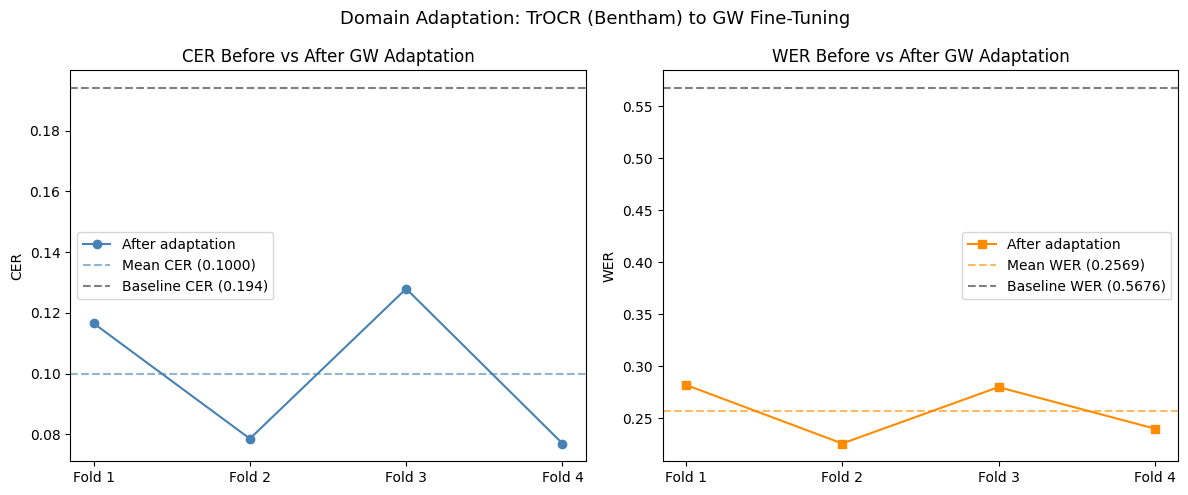

In [22]:
folds = results_df["fold"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# CER plot
axes[0].plot(folds, results_df["cer"], marker="o", label="After adaptation", color="steelblue")
axes[0].axhline(results_df["cer"].mean(), linestyle="--", color="steelblue", alpha=0.6,
                label=f"Mean CER ({results_df['cer'].mean():.4f})")
axes[0].axhline(baseline_cer, linestyle="--", color="gray", alpha=1.0,
                label=f"Baseline CER ({baseline_cer})")
axes[0].set_xticks(folds)
axes[0].set_xticklabels([f"Fold {i}" for i in folds])
axes[0].set_ylabel("CER")
axes[0].set_title("CER Before vs After GW Adaptation")
axes[0].legend()
axes[0].grid(False)

# WER plot
axes[1].plot(folds, results_df["wer"], marker="s", label="After adaptation", color="darkorange")
axes[1].axhline(results_df["wer"].mean(), linestyle="--", color="darkorange", alpha=0.6,
                label=f"Mean WER ({results_df['wer'].mean():.4f})")
axes[1].axhline(baseline_wer, linestyle="--", color="gray", alpha=1.0,
                label=f"Baseline WER ({baseline_wer})")
axes[1].set_xticks(folds)
axes[1].set_xticklabels([f"Fold {i}" for i in folds])
axes[1].set_ylabel("WER")
axes[1].set_title("WER Before vs After GW Adaptation")
axes[1].legend()
axes[1].grid(False)

plt.suptitle(
    "Domain Adaptation: TrOCR (Bentham) to GW Fine-Tuning",
    fontsize=13
)
plt.tight_layout()
plt.savefig("gw_domain_adaptation_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"Results saved to: {OUTPUT_CSV.resolve()}")

Results saved to: /Users/hedyeh/Ginger_Gradient/Capstone-Project/gw_domain_adaptation_results.csv


# Summary:

1. To assess cross-domain generalization, we evaluated the Bentham-trained model on the George Washington (GW) dataset without any GW-specific training, yielding a CER of 0.1940 and WER of 0.5676, reflecting the expected domain gap between the two distinct handwriting styles and time periods. 

2. To close this gap, we performed domain adaptation by further fine-tuning the Bentham model on the GW training splits using 4-fold cross-validation, a much smaller learning rate (1e-6), and early stopping on the validation CER. 

3. The adapted model was evaluated exclusively on the held-out GW test split of each fold to ensure no data leakage. This domain adaptation step resulted in a dramatic reduction in both CER and WER (as shown in the last plot): mean CER of 0.1 and mean WER of 0.2569.

4. This actually demonstrates that even a small amount of target-domain fine-tuning improves significantly recognition performance on unseen historical handwriting styles.